# AI-Based Jira Ticket Priority Prediction System

## Exploratory Data Analysis (EDA)

**Course:** Software Engineering for Machine Learning

**Dataset:** GFG_FINAL.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/raw/GFG_FINAL.csv')
df.head(5)

,Summary,Issue key,Issue id,Issue Type,Status,Project key,Project name,Project type,Project lead,Project description,Project url,Priority,Resolution,Assignee,Reporter,Creator,Created,Updated,Last Viewed,Resolved,Affects Version/s,Affects Version/s.1,Affects Version/s.2,Affects Version/s.3,Affects Version/s.4,Affects Version/s.5,Affects Version/s.6,Affects Version/s.7,Fix Version/s,Component/s,Component/s.1,Component/s.2,Component/s.3,Due Date,Votes,Labels,Labels.1,Labels.2,Labels.3,Labels.4,Labels.5,Labels.6,Description,Environment,Original Estimate,Remaining Estimate,Time Spent,Work Ratio,Σ Original Estimate,Σ Remaining Estimate,Σ Time Spent,Security Level,Inward issue link (Blocker),Outward issue link (Blocker),Inward issue link (Cause),Outward issue link (Cause),Inward issue link (Cloners),Outward issue link (Cloners),Inward issue link (Detail),Inward issue link (Duplicate),Inward issue link (Duplicate).1,Inward issue link (Duplicate).2,Inward issue link (Duplicate).3,Inward issue link (Duplicate).4,Inward issue link (Duplicate).5,Inward issue link (Duplicate).6,Inward issue link (Duplicate).7,Inward issue link (Duplicate).8,Inward issue link (Duplicate).9,Inward issue link (Duplicate).10,Inward issue link (Duplicate).11,Inward issue link (Duplicate).12,Inward issue link (Duplicate).13,Inward issue link (Duplicate).14,Inward issue link (Duplicate).15,Inward issue link (Duplicate).16,Inward issue link (Duplicate).17,Inward issue link (Duplicate).18,Inward issue link (Duplicate).19,Inward issue link (Duplicate).20,Inward issue link (Duplicate).21,Inward issue link (Duplicate).22,Inward issue link (Duplicate).23,Inward issue link (Duplicate).24,Inward issue link (Duplicate).25,Inward issue link (Duplicate).26,Inward issue link (Duplicate).27,Inward issue link (Duplicate).28,Inward issue link (Duplicate).29,Inward issue link (Duplicate).30,Outward issue link (Duplicate),Outward issue link (Duplicate).1,Outward issue link (Duplicate).2,Outward issue link (Duplicate).3,Outward issue link (Duplicate).4,Outward issue link (Duplicate).5,Outward issue link (Duplicate).6,Inward issue link (Follows),Outward issue link (Follows),Outward issue link (Follows).1,Inward issue link (Part),Outward issue link (Part),Inward issue link (Reference),Inward issue link (Reference).1,Outward issue link (Reference),Outward issue link (Reference).1,Outward issue link (Reference).2,Outward issue link (Reference).3,Outward issue link (Reference).4,Outward issue link (Regression),Attachment,Attachment.1,Attachment.2,Attachment.3,Attachment.4,Attachment.5,Attachment.6,Attachment.7,Attachment.8,Attachment.9,Attachment.10,Attachment.11,Attachment.12,Attachment.13,Attachment.14,Attachment.15,Attachment.16,Attachment.17,Attachment.18,Attachment.19,Attachment.20,Attachment.21,Attachment.22,Attachment.23,Attachment.24,Custom field (Accept),Custom field (Actual Result),Custom field (Add-on Type),Custom field (Affects Clover-for-Eclipse),Custom field (Animal),Custom field (Atlassian Sweeps),Custom field (Attendees),Custom field (Backlog Order),Custom field (Backlog Order (Obsolete)),Custom field (Birthday),Custom field (Budget),Custom field (Bug Fix Policy),Custom field (Bug/Suggestion Type),Custom field (Bugmaster Rank),Custom field (Business Value),Custom field (Business Value).1,Custom field (CVE ID),Custom field (CVSS Score),Custom field (CVSS Severity),Custom field (CVSSv3 Vector),Custom field (Category),Custom field (Comments),Custom field (Company),Custom field (Company Name),Custom field (Complexity),Custom field (Confidence Level),Custom field (Confluence Page Id),Custom field (Contact Email),Custom field (Contact Name),Custom field (Credit),Custom field (Current Status),Custom field (Customer Email),Custom field (Date of First Response),Custom field (Demo Cascader),Custom field (Deployment Type),Custom field (Designer),Custom field (Dev Provided By),Custom field (Developed By),Custom field (Development Effort),Custom field (Do you intend to migrate to th

In [3]:
df.shape

(49000, 491)

In [4]:
df.columns.tolist()

['Summary',
 'Issue key',
 'Issue id',
 'Issue Type',
 'Status',
 'Project key',
 'Project name',
 'Project type',
 'Project lead',
 'Project description',
 'Project url',
 'Priority',
 'Resolution',
 'Assignee',
 'Reporter',
 'Creator',
 'Created',
 'Updated',
 'Last Viewed',
 'Resolved',
 'Affects Version/s',
 'Affects Version/s.1',
 'Affects Version/s.2',
 'Affects Version/s.3',
 'Affects Version/s.4',
 'Affects Version/s.5',
 'Affects Version/s.6',
 'Affects Version/s.7',
 'Fix Version/s',
 'Component/s',
 'Component/s.1',
 'Component/s.2',
 'Component/s.3',
 'Due Date',
 'Votes',
 'Labels',
 'Labels.1',
 'Labels.2',
 'Labels.3',
 'Labels.4',
 'Labels.5',
 'Labels.6',
 'Description',
 'Environment',
 'Original Estimate',
 'Remaining Estimate',
 'Time Spent',
 'Work Ratio',
 'Σ Original Estimate',
 'Σ Remaining Estimate',
 'Σ Time Spent',
 'Security Level',
 'Inward issue link (Blocker)',
 'Outward issue link (Blocker)',
 'Inward issue link (Cause)',
 'Outward issue link (Cause)',
 

In [5]:
# Select only required columns
jira_df = df[['Summary', 'Priority']].copy()

jira_df.head()

,Summary,Priority
0,Authentication failed when attempting Fetch command,High
1,OAuth token keeps expiring,Low
2,Mercurial: No column for revision/changeset number,NaN
3,Add an option to disable `git lfs ls-files` on startup,NaN
4,Unable to start SourceTree after updating from older version to 3.4.12,Medium


In [6]:
jira_df.isnull().sum()

Summary        0
Priority    7154
dtype: int64

In [7]:
# Remove rows where Priority is missing
jira_df = jira_df.dropna(subset=['Priority'])

# Reset index
jira_df = jira_df.reset_index(drop=True)

print("Dataset shape after removing missing values:")
print(jira_df.shape)

Dataset shape after removing missing values:
(41846, 2)


In [8]:
jira_df['Priority'].value_counts()

Priority
Low        37828
High        1813
Medium      1323
Highest      882
Name: count, dtype: int64

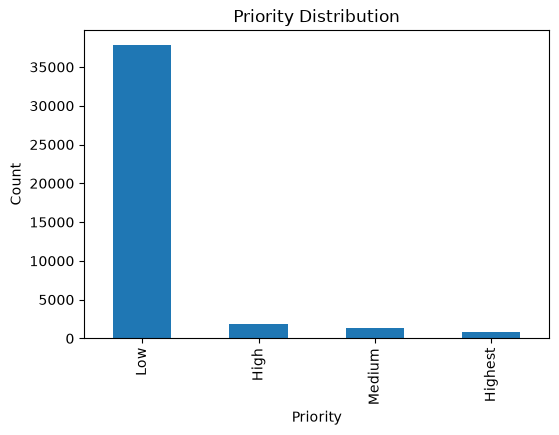

In [9]:
jira_df['Priority'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [10]:
jira_df['Priority'].value_counts()

Priority
Low        37828
High        1813
Medium      1323
Highest      882
Name: count, dtype: int64

In [11]:
jira_df['Priority'].value_counts(normalize=True) * 100

Priority
Low        90.398126
High        4.332553
Medium      3.161593
Highest     2.107728
Name: proportion, dtype: float64

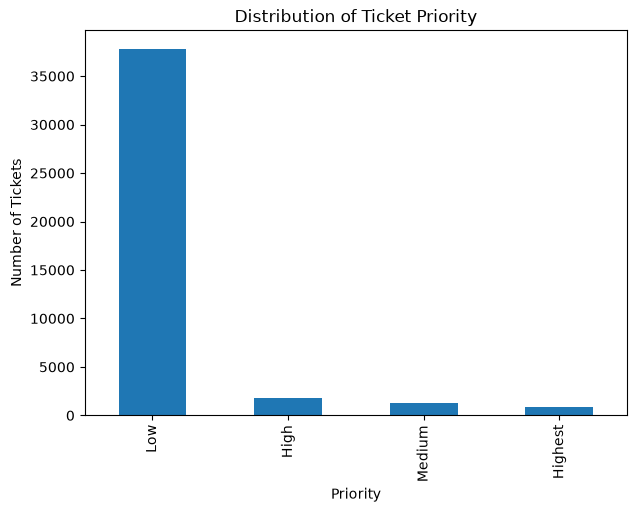

In [12]:
plt.figure(figsize=(7,5))

jira_df['Priority'].value_counts().plot(kind='bar')

plt.title("Distribution of Ticket Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

The target variable (Priority) is highly imbalanced. Approximately 90.4% of the records belong to the Low priority class, while the remaining classes constitute less than 10% of the dataset. Hence, evaluation metrics beyond accuracy will be used. SO we will use LogisticRegression(class_weight='balanced'), so that more importance is given to minority classes.

In [13]:
# Display first 10 ticket summaries
jira_df['Summary'].head(10)

0                        Authentication failed when attempting Fetch command
1                                                 OAuth token keeps expiring
2    Unable to start SourceTree after updating from older version to 3.4.12 
3                                              Keesp Asking for GitHub Login
4                 Dark Theme - history changed files not displayed correctly
5                                     Unable to know if the time is AM or PM
6              Fix for  Git Buffer Overflow - CVE-2022-41903, CVE-2022-23521
7                                       Failed to start after windows update
8                                          History view column sizes madness
9                         Upadate embedded Git binary and create new release
Name: Summary, dtype: str

In [14]:
# Display 10 random summaries
jira_df['Summary'].sample(10, random_state=42)



29821         Not able to check out remote branch with pipe (vertical line) character
24319               'Keep staged changes' checkbox doesn't work when stashing changes
33766                                                      commit time in 24h format 
24445    Authentication failure - Keeps attempting to authenticate on single request.
5014                         Code signing timestamp is missing from SourceTree v3.2.6
10210                                                    On push not select baranches
12286                                 Impossible to access to the Remote Account page
18701                                       Калькулятор скидки: не правильный расчет.
23072                                                       添加大量文件后，SourceTree会长时间无响应
28147                                        Custom Actions broken in Beta-3.3.0-3678
Name: Summary, dtype: str

In [15]:
# Length of each ticket summary
jira_df['Summary_Length'] = jira_df['Summary'].str.len()

jira_df['Summary_Length'].describe()

count    41846.000000
mean        50.174473
std         23.040587
min          2.000000
25%         33.000000
50%         48.000000
75%         65.000000
max        240.000000
Name: Summary_Length, dtype: float64

In [16]:
jira_df.head()

,Summary,Priority,Summary_Length
0,Authentication failed when attempting Fetch command,High,52
1,OAuth token keeps expiring,Low,26
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71
3,Keesp Asking for GitHub Login,Medium,29
4,Dark Theme - history changed files not displayed correctly,Low,58


This observation is important. Summary is neither too large nor too short. Also since mean is 50 and median is 48, so data is not highly skewed.
TF-iDF is good choice for this. If summaries had 5000-10000 characters, bERT or transformer would be needed.

✅ TF-IDF + Logistic Regression

The average ticket summary length is approximately 50 characters, with most summaries ranging between 33 and 65 characters. The relatively short and consistent length makes TF-IDF vectorization a suitable representation technique.

In [17]:
jira_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41846 entries, 0 to 41845
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Summary         41846 non-null  str  
 1   Priority        41846 non-null  str  
 2   Summary_Length  41846 non-null  int64
dtypes: int64(1), str(2)
memory usage: 3.1 MB


In [18]:
jira_df['Priority'].unique()

<ArrowStringArray>
['High', 'Low', 'Medium', 'Highest']
Length: 4, dtype: str

In [19]:
jira_df['Priority'].nunique()

4

The dataset was cleaned by removing records with missing values in the target attribute (Priority). The resulting dataset contains 41,846 labeled Jira tickets. The project uses the Summary field as the textual input and Priority as the target variable. Four priority classes are present: Low, Medium, High, and Highest. The dataset is highly imbalanced, with approximately 90% of the tickets belonging to the Low priority class.

In [20]:
jira_df.shape

(41846, 3)

In [21]:
# Save cleaned dataset
jira_df.to_csv("../data/processed/jira_cleaned.csv", index=False)